In [12]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from scipy.io import loadmat
from sklearn.cluster import KMeans
from sklearn.metrics.cluster import homogeneity_score
import seaborn as sns

In [18]:
sns.set_context('talk')
sns.set_style('white')

base_dir = '/media/mattw/fly/behavior'
embeddings_dir = os.path.join(base_dir, 'embeddings_umap')
fig_save_path = '/home/mattw/Dropbox/research-text/papers/2021-daart/figs/abdomen-raise'

model_type = 'gru'
umap_dim = 2
n_clusters_list = [5, 10, 15, 20, 25, 30, 35]

expt_ids_test = [
    '2019_06_26_fly2',
    '2019_08_14_fly1',
    '2019_08_20_fly3',
    '2019_10_14_fly2',
    '2019_10_21_fly1',
]

batch_size = 2000

In [28]:
results_df = []

for expt_id in expt_ids_test:
    
    print('processing %s' % expt_id)
    
    # hand labels
    hand_labels_file = os.path.join(
        base_dir, 'labels_deepethogram', 'DATA', expt_id, expt_id + '_labels.csv')

    # load hand labels
    labels = np.genfromtxt(hand_labels_file, delimiter=',', dtype=np.int, encoding=None)
    labels = labels[1:, 1:]  # get rid of headers, etc.
    states = np.argmax(labels, axis=1)
    cutoff = int(np.floor(states.shape[0] / batch_size)) * batch_size
    states = states[:cutoff]
    true_idxs = np.where(states > 0)[0]
    
    for labels_present in [True, False]:
    
        if labels_present is False:
#             embeddings_file = os.path.join(
#                 embeddings_dir, '%s_model%s_label%s_nc5_nd%i.mat' % (
#                     expt_id, model_type, labels_present, umap_dim))
            embeddings_file = os.path.join(
                embeddings_dir, 'no-abdomen', '%s_model%s_label%s_nc5_nd%i.mat' % (
                    expt_id, model_type, True, umap_dim))
            data = loadmat(embeddings_file)
            # original latent 
            latents = data['label_latent']
            # latent embedding after umap
            embeddings = data['label_latent_embeds']
        else:
            embeddings_file = os.path.join(
                embeddings_dir, '%s_model%s_label%s_nc5_nd%i.npy' % (
                    expt_id, model_type, labels_present, umap_dim))
            embeddings = np.load(embeddings_file)       
        
        for n_clusters in n_clusters_list:
            
            kmeans = KMeans(n_clusters=n_clusters, random_state=42).fit(embeddings)
            labels_umap = kmeans.predict(embeddings)
            
            score_label = homogeneity_score(states[true_idxs], labels_umap[true_idxs])
            
            results_df.append(pd.DataFrame({
                'expt_id': expt_id,
                'labels': str(labels_present),
                'n_clusters': n_clusters,
                'score': score_label
            }, index=[0]))
            
results_df = pd.concat(results_df)

processing 2019_06_26_fly2
processing 2019_08_14_fly1
processing 2019_08_20_fly3
processing 2019_10_14_fly2
processing 2019_10_21_fly1


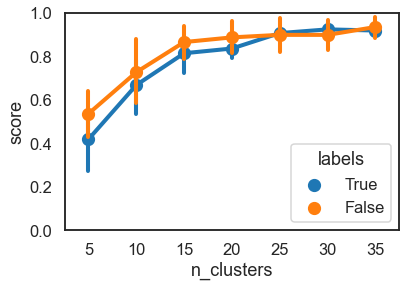

In [29]:
# sns.relplot(x='n_clusters', y='score', hue='labels', data=results_df, kind='line')
sns.pointplot(
    x='n_clusters', y='score', hue='labels', data=results_df, 
    estimator=lambda x: np.mean(x), ci=95)
plt.ylim([0, 1])
# plt.savefig(os.path.join(fig_save_path, 'cluster_homogeneity.pdf'))
plt.show()

In [38]:
expt_id = '2019_06_26_fly2'
    
# hand labels
hand_labels_file = os.path.join(
    base_dir, 'labels_deepethogram', 'DATA', expt_id, expt_id + '_labels.csv')

# load hand labels
labels = np.genfromtxt(hand_labels_file, delimiter=',', dtype=np.int, encoding=None)
labels = labels[1:, 1:]  # get rid of headers, etc.
states = np.argmax(labels, axis=1)
cutoff = int(np.floor(states.shape[0] / batch_size)) * batch_size
states = states[:cutoff]
true_idxs = np.where(states > 0)[0]

# with labels
embeddings_file = os.path.join(
    embeddings_dir, 'no-abdomen', '%s_model%s_labelTrue_nc5_nd%i.mat' % (
        expt_id, model_type, umap_dim))
embedding_wlabels = loadmat(embeddings_file)['label_latent_embeds']
# embeddings_file = os.path.join(
#     embeddings_dir, '%s_model%s_labelTrue_nc5_nd%i.npy' % (
#         expt_id, model_type, umap_dim))
# embedding_wlabels = np.load(embeddings_file)

# without labels
embeddings_file = os.path.join(
    embeddings_dir, '%s_model%s_labelFalse_nc5_nd%i.mat' % (
        expt_id, model_type, umap_dim))
embedding_wolabels = loadmat(embeddings_file)['label_latent_embeds']

In [39]:
def plot_embedding(pts, labels, label_names, markersize=15, alpha=0.5, legend=True):
    
#     prop_cycle = plt.rcParams['axes.prop_cycle']
#     colors = prop_cycle.by_key()['color']
    colors = [
        (1, 1, 1, 1),
        (233 / 255, 94 / 255, 13 / 255, 1),
        (55 / 255, 160 / 255, 85 / 255, 1),
        (226 / 255, 46 / 255, 39 / 255, 1),
        (121 / 255, 110 / 255, 178 / 255, 1),
        (18 / 255, 117 / 255, 207 / 255, 1),
    ]

    markersize = 15
    alpha = 0.5

    fig = plt.figure(figsize=(8, 8))
    plt.plot(pts[:, 0], pts[:, 1], '.k', markersize=1, alpha=0.25)
    for l_idx, l in enumerate(label_names):
        if l == 'background': 
            continue
        idxs = np.where(labels == l_idx)[0]
        plt.plot(
            pts[idxs, 0], pts[idxs, 1], '.', markersize=markersize, alpha=alpha,
            markerfacecolor=colors[l_idx], markeredgecolor=colors[l_idx],
            markeredgewidth=0, label=l)
    plt.xlabel('UMAP dim 0')
    plt.ylabel('UMAP dim 1')
    if legend:
        from matplotlib.legend_handler import HandlerLine2D
        def update_prop(handle, orig):
            handle.update_from(orig)
            handle.set_alpha(1)
            handle.set_markersize(20)
        plt.legend(handler_map={plt.Line2D:HandlerLine2D(update_func=update_prop)})
    
    return fig

In [41]:
fig_save_path

'/home/mattw/Dropbox/research-text/papers/2021-daart/figs/abdomen-raise'

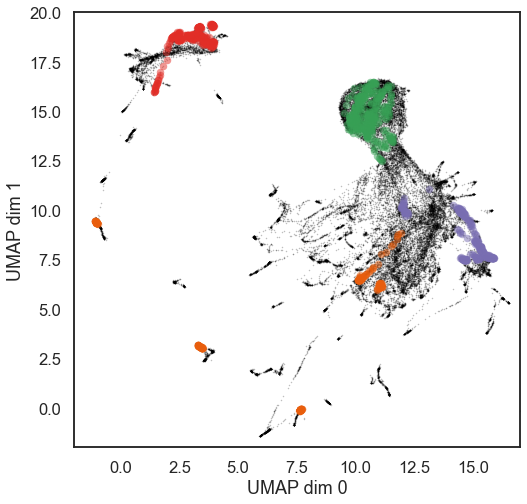

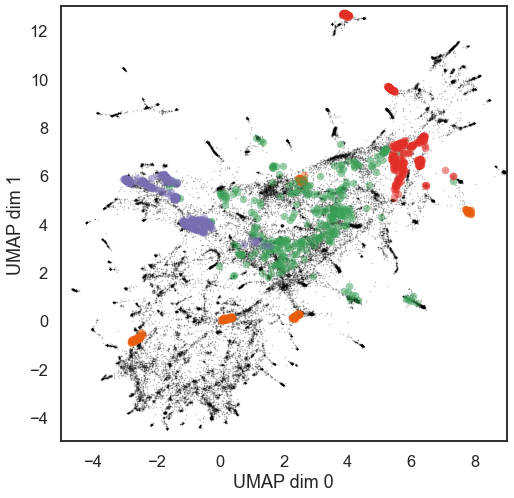

In [42]:
save_figs = True

label_names = ['background', 'still', 'walk', 'front groom', 'back groom'] #, 'abdomen raise']

fig = plot_embedding(
    pts=embedding_wlabels, labels=states, label_names=label_names, legend=False,
    markersize=15, alpha=0.5)
# no-abdomen
plt.xlim([-2, 17])
plt.ylim([-2, 20])
# w/ abdomen
# plt.xlim([-11, 11])
# plt.ylim([-11, 19])
# if save_figs:
#     plt.savefig(os.path.join(fig_save_path, '%s_wlabels.pdf' % expt_id))
plt.show()

fig = plot_embedding(
    pts=embedding_wolabels, labels=states, label_names=label_names, legend=False,
    markersize=15, alpha=0.5)
plt.xlim([-5, 9])
plt.ylim([-5, 13])
if save_figs:
    plt.savefig(os.path.join(fig_save_path, '%s_wolabels.pdf' % expt_id))
plt.show()